# Case 4: Minimize CVaR while keeping Tracking Error below a maximun value

## Data load

In [1]:
import numpy as np
import pandas as pd
import cvxpy as cp
import tensorflow as tf

import data_management as dm
from portfolios import Portfolio, Portfolio_Collection
from models import MPOModel
import risk_measures as rm
from utils import sparsemax

import warnings

warnings.filterwarnings("ignore")
tf.keras.backend.set_floatx("float32")

### Index and components

In [2]:
data, data_idx = dm.DataManagement.get_data(
    asset_price_path="../data/data_comp_SP500.csv",
    idx_price_path="../data/data_idx_SP500.csv",
)

### Train/Test split

In [3]:
# Desired dates.
ds_start_date = "2010-07-15"
ds_end_date = "2024-10-18"
train_start_date = "2019-12-31"
train_end_date = "2020-12-31"
test_start_date = "2021-01-01"
test_end_date = "2021-06-30"

# Sync dataframes
data, data_idx = dm.DataManagement.sync_dataframes(data, data_idx)
data_log_ret = dm.DataManagement.convert_prices_to_log_returns(data)

# Compute logarithmic returns.
data_idx_log_ret = dm.DataManagement.convert_prices_to_log_returns(data_idx)

# Filter dates.
data_log_ret = data_log_ret.loc[ds_start_date:ds_end_date, :]
data_idx_log_ret = data_idx_log_ret.loc[ds_start_date:ds_end_date, :]

# Train and test datasets.
X_train, y_train, X_test, y_test = dm.DataManagement.train_test_split_by_date(
    X=data_log_ret,
    y=data_idx_log_ret,
    train_start_date=train_start_date,
    train_end_date=train_end_date,
    test_start_date=test_start_date,
    test_end_date=test_end_date,
    train_freq="D",
)

In [4]:
risk_free_return = np.float32(0.08 / 252)
# risk_free_return = 0.0

## Portfolio optimization using SKFOLIO

In [5]:
from skfolio import RiskMeasure
from skfolio.optimization import MeanRisk, ObjectiveFunction

In [ ]:
max_te = 0.004
skfolio_portfolio_name = "Case 4 - SKFOLIO"
skfolio_portfolio_opt = MeanRisk(
    objective_function=ObjectiveFunction.MINIMIZE_RISK,
    risk_measure=RiskMeasure.CVAR,
    min_weights=0,  # -1.0 for allowing short selling. 0.0 for no short selling.
    max_tracking_error=max_te,
    portfolio_params=dict(name=max_te, tag=f"Tracking {max_te * 100}%"),
)
skfolio_portfolio_opt.fit(X_train, y_train)

MeanRisk(max_tracking_error=0.004, min_weights=0,
         portfolio_params={'name': 0.004, 'tag': 'Tracking 0.4%'},
         risk_measure=CVaR)

In [7]:
skfolio_portfolio = Portfolio(
    name=skfolio_portfolio_name,
    asset_weights=skfolio_portfolio_opt.weights_,
    asset_names=X_train.columns,
)

Number of assets in portfolio: 75


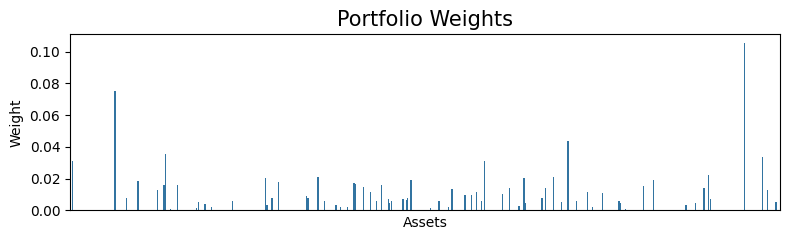

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & A & AAPL & ABT & ACGL & ACN & ADBE & ADI & ADM & ADP & ADSK & AEE & AEP & AES & AFL & AIG & AIZ & AJG & AKAM & ALB & ALGN & ALL & AMAT & AMD & AME & AMGN & AMP & AMT & AMZN & ANSS & AON & AOS & APA & APD & APH & ARE & ATO & AVB & AVGO & AVY & AWK & AXON & AXP & AZO & BA & BAC & BALL & BAX & BBY & BDX & BEN & BG & BIIB & BK & BKNG & BKR & BLDR & BLK & BMY & BR & BRO & BSX & BWA & BX & BXP & C & CAG & CAH & CAT & CB & CBOE & CBRE & CCI & CCL & CDNS & CE & CF & CHD & CHRW & CHTR & CI & CINF & CL & CLX & CMCSA & CME & CMG & CMI & CMS

In [8]:
skfolio_portfolio.plot_weights(
    plot_ucits_limits=False,
    skip_zero_weights=False,
    zero_threshold=1e-3,
    save_as="../results/Case_04/MinCVaR_traking_skfolio_optimizer_portfolio_weights.png",
    figsize=(8, 2.5),
)

Number of assets in portfolio: 75


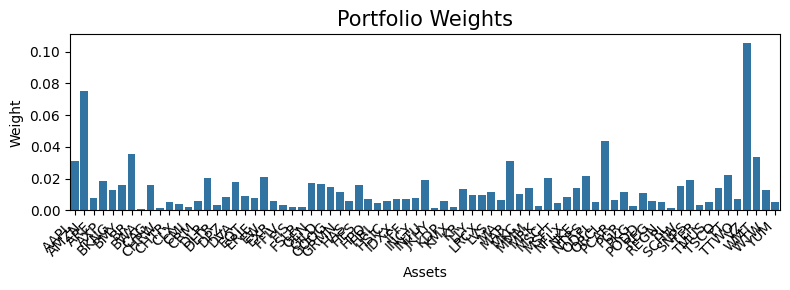

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & AAPL & AMZN & ARE & AXP & BKNG & BMY & BR & BWA & CAG & CHRW & CHTR & CLX & CMI & CRM & DLR & DLTR & DPZ & DVA & EQT & ERIE & EW & EXR & FFIV & FIS & FSLR & GEN & GILD & GOOG & GRMN & HAS & HES & HPQ & HRL & HSIC & IDXX & IFF & INCY & INTU & JKHY & KDP & KMX & KR & LLY & LRCX & LVS & MA & MAR & MKC & MMM & MRK & MSCI & MSFT & NFLX & NKE & NTRS & ODFL & ORCL & PCAR & PGR & PKG & PODD & REG & REGN & RL & SCHW & SNPS & TER & TMUS & TSCO & TT & TTWO & VZ & WMT & WTW & YUM \\
\midrule
Weight & 0.030848 & 0.075538 & 0.007921 & 0.018329 & 0.012925 & 0.016083 & 0.035460 & 0.001084 & 0.015765 & 0.001466 & 0.005263 & 0.003870 & 0.001970 & 0.005683 & 0.020230 & 0.003520 & 0.008059 & 0.017996 & 0.008799 & 0.007688 & 0.020886 & 0.005775 & 0.003553 & 0.001978 & 0.001997 & 0.017114 & 0.016550 & 0.014725 & 0.011544 & 0.005755 & 0.015850 & 0.006948 & 0.004792 & 0.005652 & 0.007203 & 0.006867 & 0.00

In [9]:
skfolio_portfolio.plot_weights(
    plot_ucits_limits=False,
    skip_zero_weights=True,
    zero_threshold=1e-3,
    save_as="../results/Case_04/MinCVaR_traking_skfolio_optimizer_portfolio_weights_no_zeros.png",
    figsize=(8, 3),
)

## Portfolio optimization using gradient descent

In [ ]:
def custom_loss_function(l_cvar=0.0, l_te=0.0, max_tracking_error=0.0):
    def loss_function(
        assets_rets,  # Assets returns
        w,  # Portfolio weights
        idx=None,  # Index returns
    ):
        # We want the lambdas to be positive.
        lambda_cvar = tf.nn.relu(l_cvar)
        lambda_te = tf.nn.relu(l_te)

        # Portfolio returns.
        p_rets = tf.matmul(assets_rets, w)

        # Portfolio returns.
        p_rets = tf.matmul(assets_rets, w)

        ###############
        # CVaR
        ###############
        # Calculate CVaR at 95%.
        # This function gives the result in positive.
        cvar = rm.RiskMeasures.CVaR_tf(x=p_rets, alpha=0.05)

        ###############
        # TRACKING ERROR
        ###############
        # Calculate Tracking Error (standard deviation of the difference between portfolio returns and index returns).
        te = rm.RiskMeasures.TrackingError_tf(x=p_rets, y=idx)
        te_penalty = tf.nn.relu(te - max_tracking_error)

        # Update the loss.
        loss = lambda_cvar * cvar + lambda_te * te_penalty

        return {
            "loss": loss,  # Only for training, without converting to numpy.
            "weights": w.numpy(),
            "metrics": {
                "loss": loss.numpy(),
                "loss_cvar": (lambda_cvar * cvar).numpy(),
                "loss_te": (lambda_te * te_penalty).numpy(),
            },
        }

    return loss_function

In [ ]:
def custom_get_best_weights():
    def get_best_weights(history: list) -> np.ndarray:
        weights = pd.DataFrame([h["weights"].squeeze() for h in history])
        metrics = pd.DataFrame([h["metrics"] for h in history])
        idx_min_loss = metrics["loss"].idxmin()
        selected_weights = weights.loc[idx_min_loss].to_numpy()
        return selected_weights.squeeze()

    return get_best_weights

In [ ]:
def custom_weights_function():
    return sparsemax

In [ ]:
num_assets = X_train.shape[1]
loss_function = custom_loss_function(l_cvar=1.0 / 0.01, l_te=3 / 0.01, max_tracking_error=max_te)
weights_function = custom_weights_function()
get_best_weights_function = custom_get_best_weights()
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5)

mpo = MPOModel(
    num_assets=num_assets,
    loss_function=loss_function,
    weights_function=weights_function,
    get_best_weights_function=get_best_weights_function,
    optimizer=optimizer,
    random_weight_init=False,
)

In [14]:
history = mpo.fit(x=X_train, idx=y_train, epochs=6000)

100%|██████████| 6000/6000 [01:01<00:00, 97.01it/s] 


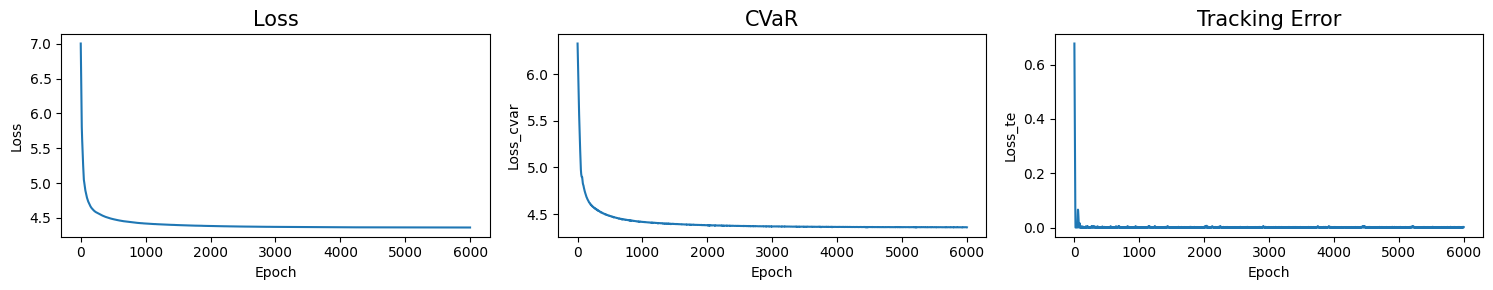

In [15]:
mpo.plot_all_training_metrics(
    save_as="../results/Case_04/MinCVaR_Tracking_gd_optimizer_training_metrics.png",
    titles={
        "loss": "Loss",
        "loss_cvar": "CVaR",
        "loss_te": "Tracking Error",
    },
)

In [16]:
gd_portfolio_name = "Case 4 - GD"
gd_portfolio = Portfolio(
    name=gd_portfolio_name,
    asset_weights=mpo.get_best_weights(),
    asset_names=X_train.columns,
)

Number of assets in portfolio: 82


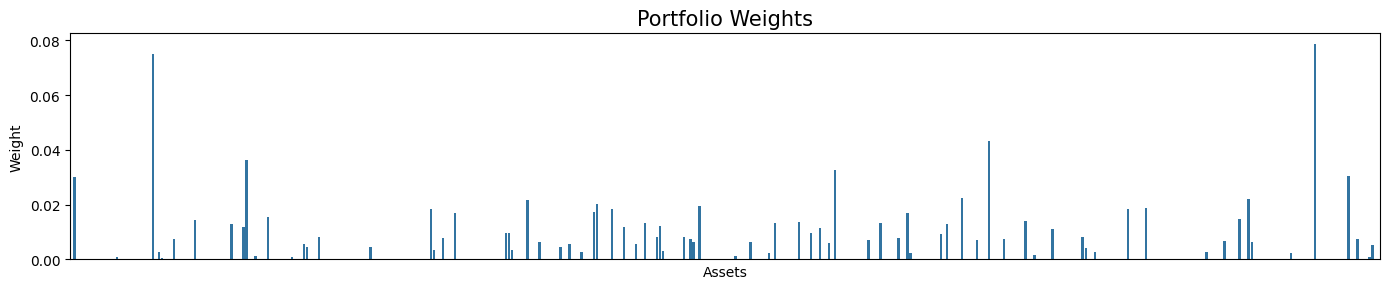

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & A & AAPL & ABT & ACGL & ACN & ADBE & ADI & ADM & ADP & ADSK & AEE & AEP & AES & AFL & AIG & AIZ & AJG & AKAM & ALB & ALGN & ALL & AMAT & AMD & AME & AMGN & AMP & AMT & AMZN & ANSS & AON & AOS & APA & APD & APH & ARE & ATO & AVB & AVGO & AVY & AWK & AXON & AXP & AZO & BA & BAC & BALL & BAX & BBY & BDX & BEN & BG & BIIB & BK & BKNG & BKR & BLDR & BLK & BMY & BR & BRO & BSX & BWA & BX & BXP & C & CAG & CAH & CAT & CB & CBOE & CBRE & CCI & CCL & CDNS & CE & CF & CHD & CHRW & CHTR & CI & CINF & CL & CLX & CMCSA & CME & CMG & CMI & CMS

In [17]:
gd_portfolio.plot_weights(
    plot_ucits_limits=False,
    skip_zero_weights=False,
    save_as="../results/Case_04/MinCVaR_Tracking_gd_optimizer_portfolio_weights.png",
    figsize=(14, 3),
)

Number of assets in portfolio: 82


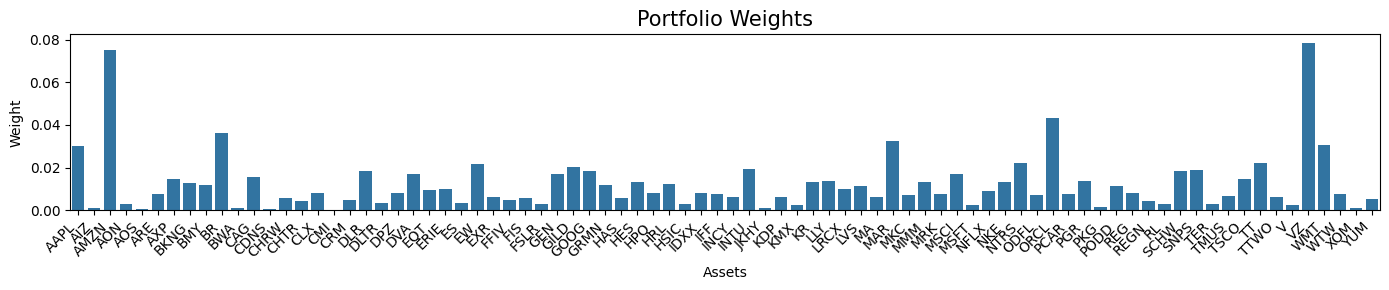

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & AAPL & AIZ & AMZN & AON & AOS & ARE & AXP & BKNG & BMY & BR & BWA & CAG & CDNS & CHRW & CHTR & CLX & CMI & CRM & DLR & DLTR & DPZ & DVA & EQT & ERIE & ES & EW & EXR & FFIV & FIS & FSLR & GEN & GILD & GOOG & GRMN & HAS & HES & HPQ & HRL & HSIC & IDXX & IFF & INCY & INTU & JKHY & KDP & KMX & KR & LLY & LRCX & LVS & MA & MAR & MKC & MMM & MRK & MSCI & MSFT & NFLX & NKE & NTRS & ODFL & ORCL & PCAR & PGR & PKG & PODD & REG & REGN & RL & SCHW & SNPS & TER & TMUS & TSCO & TT & TTWO & V & VZ & WMT & WTW & XOM & YUM \\
\midrule
Weight & 0.030262 & 0.000959 & 0.074961 & 0.002818 & 0.000558 & 0.007585 & 0.014429 & 0.012852 & 0.011842 & 0.036200 & 0.001271 & 0.015563 & 0.000790 & 0.005513 & 0.004524 & 0.008273 & 0.000168 & 0.004591 & 0.018561 & 0.003457 & 0.007969 & 0.016948 & 0.009730 & 0.009835 & 0.003320 & 0.021628 & 0.006411 & 0.004668 & 0.005584 & 0.002864 & 0.017155 & 0.020088 & 0

In [18]:
gd_portfolio.plot_weights(
    plot_ucits_limits=False,
    skip_zero_weights=True,
    save_as="../results/Case_04/MinCVaR_Tracking_gd_optimizer_portfolio_weights_no_zeros.png",
    figsize=(14, 3),
)

## Comparison

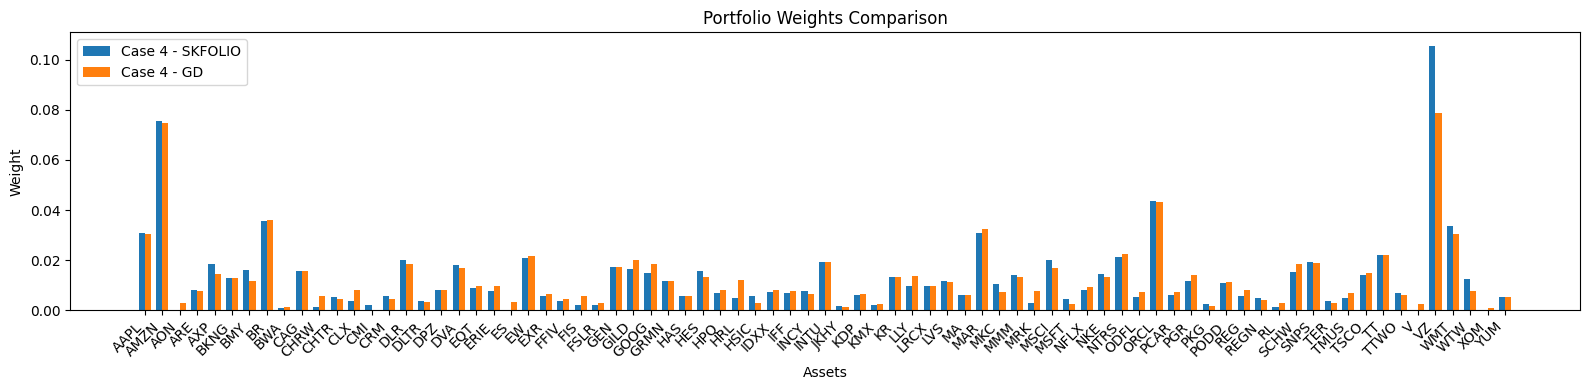

                      AAPL      AMZN       AON       ARE       AXP      BKNG  \
Case 4 - SKFOLIO  0.030848  0.075538  0.000000  0.007921  0.018329  0.012925   
Case 4 - GD       0.030262  0.074961  0.002818  0.007585  0.014429  0.012852   

                       BMY       BR       BWA       CAG      CHRW      CHTR  \
Case 4 - SKFOLIO  0.016083  0.03546  0.001084  0.015765  0.001466  0.005263   
Case 4 - GD       0.011842  0.03620  0.001271  0.015563  0.005513  0.004524   

                       CLX      CMI       CRM       DLR      DLTR       DPZ  \
Case 4 - SKFOLIO  0.003870  0.00197  0.005683  0.020230  0.003520  0.008059   
Case 4 - GD       0.008273  0.00000  0.004591  0.018561  0.003457  0.007969   

                       DVA       EQT      ERIE       ES        EW       EXR  \
Case 4 - SKFOLIO  0.017996  0.008799  0.007688  0.00000  0.020886  0.005775   
Case 4 - GD       0.016948  0.009730  0.009835  0.00332  0.021628  0.006411   

                      FFIV       FIS      FSL

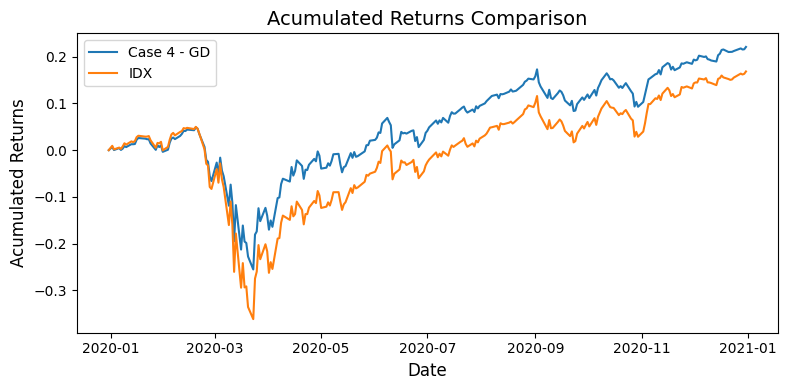

                  Std    Sharpe  TrackingError       VaR      CVaR  \
Case 4 - GD  0.018103  0.031009       0.004001  0.027631  0.043603   
IDX          0.021113  0.016771       0.000000  0.033728  0.056878   

             WeightsOver10pct  WeightsOver5pct  
Case 4 - GD               0.0         0.153569  
IDX                       NaN              NaN  


In [ ]:
# Allows us to store and compare different portfolios.
portfolios = Portfolio_Collection(portfolio_names=[], portfolio_weights=[], asset_names=X_train.columns)

portfolios.replace_or_add_portfolio(
    name=skfolio_portfolio.name,
    new_portfolio=skfolio_portfolio,
)

portfolios.replace_or_add_portfolio(name=gd_portfolio.name, new_portfolio=gd_portfolio)

portfolios.plot_weight_comparison(
    portfolio_names=[
        skfolio_portfolio.name,
        gd_portfolio.name,
    ],
    plot_ucits_limits=False,
    skip_zero_weights=True,
    zero_threshold=1e-3,
    save_as="../results/Case_04/MinCVaR_Tracking_portfolio_weights_comparison.png",
    figsize=(16, 4),
)

portfolios.plot_cumulative_returns(
    asset_returns=X_train,
    idx_returns=y_train,
    portfolio_names=[
        gd_portfolio.name,
    ],
    plot_idx=True,
    comparable_returns=[],
    rf=risk_free_return,
    zero_start=True,
    save_as="../results/Case_04/MinCVaR_Tracking_portfolio_cumulative_returns_comparison.png",
    figsize=(8, 4),
)